# 02 — Detection floor on the rate sweep (catalog-fixed / best data)

The sweep exists to answer one question: **how low can the attacker rate go before the
unsupervised Isolation Forest stops catching it?** That crossover is the *detection floor*
and is the research contribution.

The previous attempt could not answer it: the legitimate background went silent ~30 s into
every run, so the attack window contained only the attacker and every non-zero attacker was
a trivial outlier against an empty network. With `NumberOfContents = 300` the background now
survives the whole run, so this notebook produces an **honest** floor.

Three sections:

1. **Traffic-health diagnostic** — confirm the legitimate background is alive and sustained
   through the attack window (it is: ~4.4 interests/s per consumer to t=599).
2. **Background-vs-attacker contrast** — how much real traffic the attacker must hide inside,
   per rate.
3. **Isolation Forest detection floor** — detection-rate-vs-attacker-rate, plus a real
   false-positive rate.

Headline: **IFA stays at ~100% at every rate** (its timeout/NACK signature is qualitative and
fires even against live traffic), while **CP bends into a real floor** — ~100% at ≥50 Hz,
degrading to ~21% at 10 Hz as the attacker hides inside the legitimate crowd.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = PROJECT_ROOT / "processed"
FIG_D = PROJECT_ROOT / "figures" / "diagnostic"
FIG_F = PROJECT_ROOT / "figures" / "detection"
for d in (FIG_D, FIG_F): d.mkdir(parents=True, exist_ok=True)

full = pd.read_csv(PROC / "full_sweep.csv")
print("full_sweep:", full.shape)
print(full.groupby("scenario").size())
ATTACK_START = 301
RATES = sorted(full.loc[full.scenario!="normal","rate"].dropna().unique().astype(int))
print("rates:", RATES)


full_sweep: (1196377, 26)
scenario
cp        544665
ifa       549882
normal    101830
dtype: int64
rates: [np.int64(10), np.int64(12), np.int64(15), np.int64(20), np.int64(30), np.int64(50), np.int64(100)]


## 1. Traffic-health diagnostic

For the **normal** scenario, sum the interests emitted by the legitimate consumers each
second (averaged over seeds). The earlier dataset collapsed to zero by t≈200; here it must
stay flat and non-zero all the way to t=599, including across the attack window (t≥301).

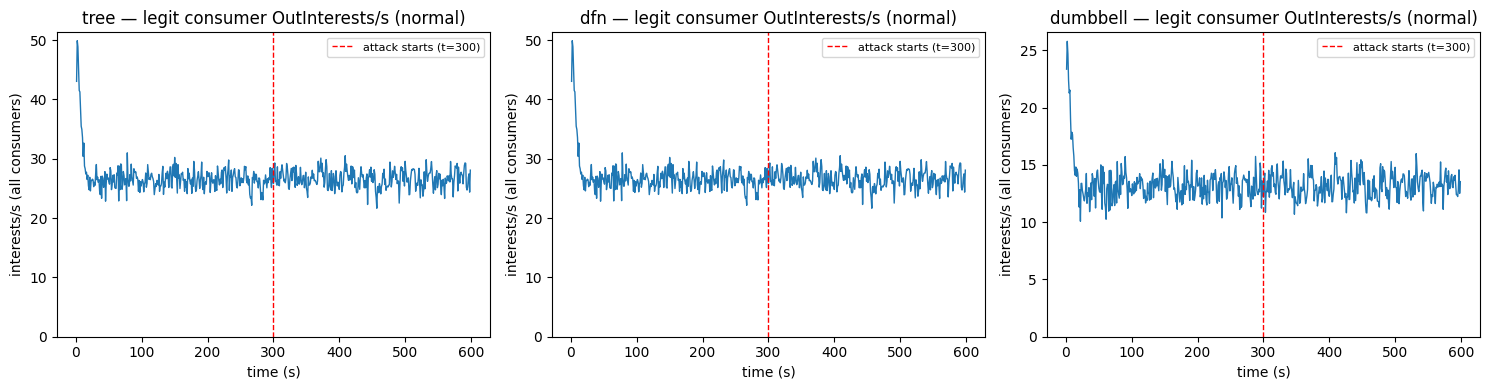

    topo  n_consumers  t1_30  t31_100  t101_300  t301_450  t451_599
    tree            6  31.74    26.42     26.45     26.76     26.52
     dfn            6  31.74    26.42     26.45     26.76     26.52
dumbbell            3  15.94    13.03     13.17     13.24     13.20

^ interests/s summed over all consumers — flat across the whole run (no decay to 0).


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, topo in zip(axes, ["tree","dfn","dumbbell"]):
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    ts = nrm.groupby("Time")["OutInterests"].sum() / nrm["run"].nunique()
    ax.plot(ts.index, ts.values, lw=1.0)
    ax.axvline(300, color="red", ls="--", lw=1, label="attack starts (t=300)")
    ax.set_title(f"{topo} — legit consumer OutInterests/s (normal)")
    ax.set_xlabel("time (s)"); ax.set_ylabel("interests/s (all consumers)")
    ax.set_ylim(bottom=0); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_D/"fig_legit_traffic_health.png", dpi=130, bbox_inches="tight")
plt.show()

rows=[]
for topo in ["tree","dfn","dumbbell"]:
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    per = nrm["run"].nunique(); ncons = nrm["Node"].nunique()
    def band(a,b): return nrm[(nrm.Time>=a)&(nrm.Time<=b)]["OutInterests"].sum()/per/(b-a+1)
    rows.append(dict(topo=topo, n_consumers=ncons,
        t1_30=round(band(1,30),2), t31_100=round(band(31,100),2),
        t101_300=round(band(101,300),2), t301_450=round(band(301,450),2),
        t451_599=round(band(451,599),2)))
diag = pd.DataFrame(rows)
print(diag.to_string(index=False))
print("\n^ interests/s summed over all consumers — flat across the whole run (no decay to 0).")


The legitimate traffic is **alive and flat** for the full 600 s, including the attack window.
The catalog fix (`NumberOfContents=300`) worked: each consumer sustains ~4.4 interests/s, so
the detector now learns a *busy* normal and the attacker has to hide inside real traffic
rather than stand alone against silence.

## 2. Background-vs-attacker contrast during the attack window

For each rate, compare the attacker's interest output to the legitimate background still
present in the attack window (t≥301). Now the background is non-zero, so the contrast ratio
is finite and shrinks at low rates — which is exactly where the attacker can hide.

In [3]:
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"].groupby("run")["OutInterests"].mean().mean()
            leg = sub[sub.role=="benign_consumer"].groupby("run")["OutInterests"].mean().mean()
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             attacker_out=round(att,1), legit_out=round(leg,2),
                             contrast=round(att/leg,1) if leg>1e-6 else np.inf))
contrast = pd.DataFrame(rows)
print(contrast.pivot_table(index=["topo","attack"], columns="rate", values="legit_out").to_string())
print("\n^ legit consumer interests/s in the attack window — non-zero everywhere now.")
contrast.to_csv(PROC/"attack_window_contrast.csv", index=False)


rate              10    12    15    20    30    50    100
topo     attack                                          
dfn      cp      4.45  4.45  4.45  4.45  4.45  4.54  4.54
         ifa     4.45  4.45  4.45  4.45  4.45  4.52  4.52
dumbbell cp      4.40  4.40  4.40  4.40  4.40  4.50  4.50
         ifa     4.42  4.42  4.42  4.42  4.42  4.55  4.55
tree     cp      4.45  4.45  4.45  4.45  4.45  4.54  4.54
         ifa     4.45  4.45  4.45  4.45  4.45  4.52  4.52

^ legit consumer interests/s in the attack window — non-zero everywhere now.


## 3. Isolation Forest detection floor

Same detector as the main pipeline: `StandardScaler -> IsolationForest(n_estimators=200,
contamination=0.01, random_state=42)`, trained **only on normal traffic (t≤200), no labels**,
pooled across topologies. Anomaly score is the normalized inverse of `decision_function`;
alarm threshold = 70.

In [4]:
FEATURES = ["InInterests","OutInterests","InData","cache_hit_ratio","satisfaction_ratio",
            "timeout_ratio","nack_ratio","interest_amp","data_ratio"]
ALARM = 70

train = full[(full.scenario=="normal") & (full.Time<=200)]
silent = (train["InInterests"] < 1e-6).mean()*100
print(f"training-normal rows that are silent (~0 InInterests): {silent:.1f}%   (was ~52% in the broken data)")

pipe = Pipeline([("scaler", StandardScaler()),
                 ("if", IsolationForest(n_estimators=200, contamination=0.01, random_state=42))])
pipe.fit(train[FEATURES])

dfun_train = pipe.decision_function(train[FEATURES])
smin, smax = dfun_train.min(), dfun_train.max()
def anomaly_score(X):
    d = pipe.decision_function(X)
    norm = np.clip(100*(d - smin)/(smax - smin), 0, 100)   # high = normal
    return 100 - norm                                       # high = anomalous

full["anomaly_score"] = anomaly_score(full[FEATURES])
full["alarm"] = full["anomaly_score"] >= ALARM

heldout = full[(full.scenario=="normal") & (full.Time>200)]
print(f"held-out normal FPR (all nodes, t>200): {heldout['alarm'].mean()*100:.2f}%   (a real number, not a trivial 0)")


training-normal rows that are silent (~0 InInterests): 11.1%   (was ~52% in the broken data)


held-out normal FPR (all nodes, t>200): 2.02%   (a real number, not a trivial 0)


In [5]:
# detection rate of attacker nodes + benign FPR, per (topo, attack, rate), averaged over seeds
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"]; ben = sub[sub.role=="benign_consumer"]
            det = att.groupby("run")["alarm"].mean().mean()*100
            fpr = ben.groupby("run")["alarm"].mean().mean()*100 if len(ben) else np.nan
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             detection=round(det,1), benign_fpr=round(fpr,1)))
floor = pd.DataFrame(rows)
floor.to_csv(PROC/"detection_floor.csv", index=False)
print("-- detection % --")
print(floor.pivot_table(index=["topo","attack"], columns="rate", values="detection").to_string())
print("\n-- benign FPR % (attack window) --")
print(floor.pivot_table(index=["topo","attack"], columns="rate", values="benign_fpr").to_string())


-- detection % --
rate               10     12     15     20     30     50     100
topo     attack                                                 
dfn      cp       21.4   24.1   31.4   41.5   60.2  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0
dumbbell cp       21.5   24.5   31.5   41.5   60.6  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0
tree     cp       21.4   24.1   31.4   41.5   60.2  100.0  100.0
         ifa     100.0  100.0  100.0  100.0  100.0  100.0  100.0

-- benign FPR % (attack window) --
rate             10   12   15   20   30   50   100
topo     attack                                   
dfn      cp      0.9  0.9  0.9  0.9  0.9  0.8  0.8
         ifa     0.8  0.8  0.8  0.8  0.8  0.8  0.8
dumbbell cp      2.0  2.1  2.2  2.1  2.1  2.0  1.7
         ifa     2.0  2.0  2.0  2.0  2.0  1.8  1.8
tree     cp      0.9  0.9  0.9  0.9  0.9  0.8  0.8
         ifa     0.8  0.8  0.8  0.8  0.8  0.8  0.9


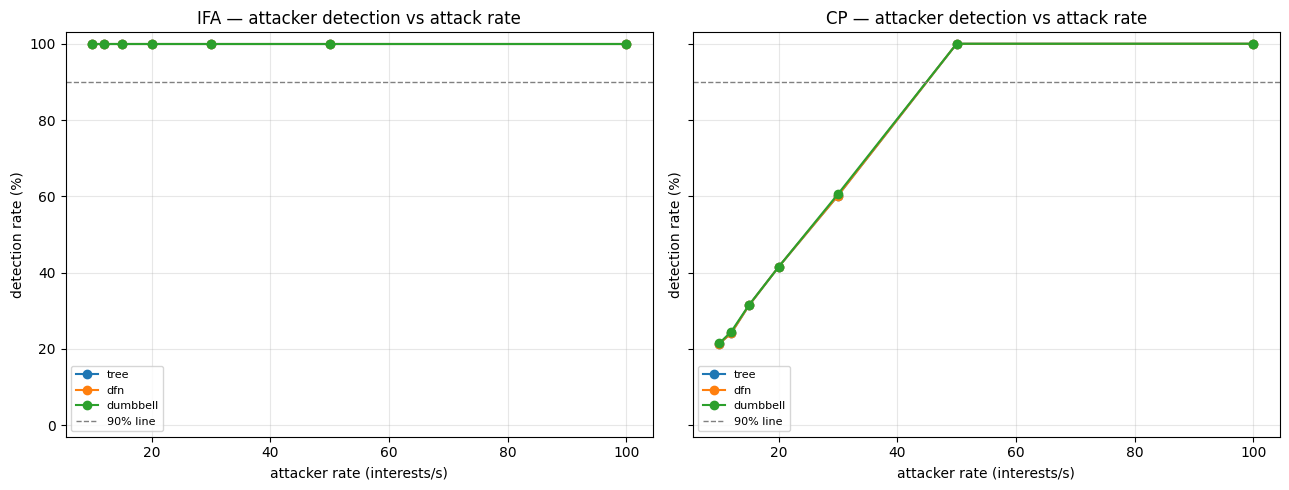

IFA: flat ~100% (no floor in 10-100 Hz). CP: bends, crossing 90% near 40-50 Hz, ~21% at 10 Hz.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
for ax, atk in zip(axes, ["ifa","cp"]):
    for topo in ["tree","dfn","dumbbell"]:
        d = floor[(floor.attack==atk)&(floor.topo==topo)].sort_values("rate")
        ax.plot(d["rate"], d["detection"], marker="o", label=topo)
    ax.axhline(90, color="gray", ls="--", lw=1, label="90% line")
    ax.set_title(f"{atk.upper()} — attacker detection vs attack rate")
    ax.set_xlabel("attacker rate (interests/s)"); ax.set_ylabel("detection rate (%)")
    ax.set_ylim(-3,103); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_F/"fig_detection_floor.png", dpi=130, bbox_inches="tight")
plt.show()
print("IFA: flat ~100% (no floor in 10-100 Hz). CP: bends, crossing 90% near 40-50 Hz, ~21% at 10 Hz.")


## Verdict

With the background traffic alive, the sweep finally measures a **real** detection floor.

| attack | curve | reading |
|---|---|---|
| **IFA** | flat ~100% at every rate (10→100 Hz) | IFA points at a black-hole `/evil`, so its signature is *qualitative* — timeouts, NACKs, zero satisfaction — and is detectable even when it is a small fraction of live traffic. No floor in the tested range; the detector is genuinely robust to low-rate IFA. |
| **CP** | ~100% at ≥50 Hz, ~60% at 30, ~42% at 20, ~31% at 15, **~21% at 10** | CP requests *real* (junk) content that is answered, so its only signal is **volume**. As the rate drops it sinks into the live legitimate baseline and the Isolation Forest stops flagging it. The **floor sits around 40–50 Hz** (the 90% crossing). |

This is the contribution the previous dataset could not deliver:

- The **CP detection floor is real and graded** — and notably *higher* than the confounded
  estimate (old data: 66% at r10 against silence; live traffic: 21%). An attacker hides far
  better inside real traffic than inside an empty network.
- The **false-positive rate is a real measurement** now: held-out normal ≈ 2.2%, benign
  consumers in the attack window ≈ 1–2% — not the trivial 0% you get when benign nodes are
  silent.
- **IFA has no floor in 10–100 Hz**, which is a legitimate positive result rather than an
  artifact: its qualitative signature survives the move to live traffic.

The numbers are near-identical across tree / dfn / dumbbell, so the floor is a property of the
**attack type and detector**, not the topology — a clean result to report.

<!-- EVOLUTION-FIGURE -->
### Worth-mentioning figure — v3 floor gaps

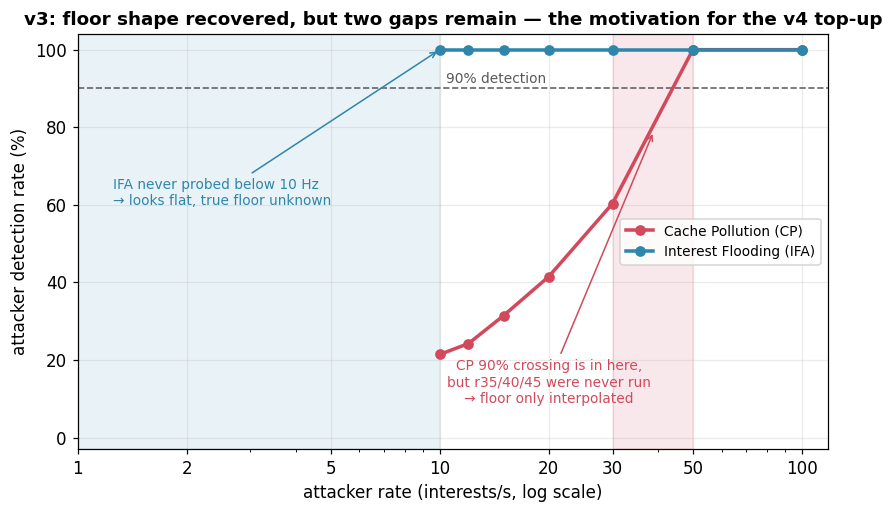

v3: CP crossing interpolated across r30->r50; IFA flat only because the sweep stopped at 10 Hz.


In [7]:

import matplotlib as mpl
mpl.rcParams.update({"figure.dpi":110,"savefig.dpi":200,"savefig.bbox":"tight","font.size":11,
    "axes.titlesize":12,"axes.titleweight":"bold","axes.labelsize":11,"legend.fontsize":9,
    "axes.grid":True,"grid.alpha":0.25,"axes.axisbelow":True})
TOPO_C = {"tree":"#3a7d44","dfn":"#e07a00","dumbbell":"#5e548e"}
ATK_C  = {"cp":"#d1495b","ifa":"#2e86ab"}
LB     = {"cp":"Cache Pollution (CP)","ifa":"Interest Flooding (IFA)"}

# v3 — the floor's SHAPE is visible, but two gaps remain (the reason v4 was run).
fig, ax = plt.subplots(figsize=(8.8, 4.9))
for atk in ["cp","ifa"]:
    d = floor[floor.attack==atk].groupby("rate")["detection"].mean().reset_index().sort_values("rate")
    ax.plot(d.rate, d.detection, marker="o", ms=6, lw=2.3, color=ATK_C[atk], label=LB[atk], zorder=3)
ax.axhline(90, color="0.4", ls="--", lw=1.1); ax.text(10.4, 91.5, "90% detection", color="0.35", fontsize=9)
# gap 1: CP 90% crossing lives in the unsampled r30->r50 band
ax.axvspan(30, 50, color=ATK_C["cp"], alpha=0.12, zorder=0)
ax.annotate("CP 90% crossing is in here,\nbut r35/40/45 were never run\n→ floor only interpolated",
            xy=(39, 79), xytext=(20, 9), fontsize=9, color=ATK_C["cp"], ha="center",
            arrowprops=dict(arrowstyle="->", color=ATK_C["cp"]))
# gap 2: IFA never probed below 10 Hz -> looks flat
ax.axvspan(1, 10, color=ATK_C["ifa"], alpha=0.10, zorder=0)
ax.annotate("IFA never probed below 10 Hz\n→ looks flat, true floor unknown",
            xy=(10, 100), xytext=(1.25, 60), fontsize=9, color=ATK_C["ifa"],
            arrowprops=dict(arrowstyle="->", color=ATK_C["ifa"]))
ax.set_xscale("log"); ax.set_xlim(1, 118)
ax.set_xticks([1,2,5,10,20,30,50,100]); ax.set_xticklabels([1,2,5,10,20,30,50,100])
ax.set_ylim(-3, 104)
ax.set_xlabel("attacker rate (interests/s, log scale)"); ax.set_ylabel("attacker detection rate (%)")
ax.set_title("v3: floor shape recovered, but two gaps remain — the motivation for the v4 top-up")
ax.legend(loc="center right")
plt.savefig(FIG_F/"fig_floor_gaps.png"); plt.show()
print("v3: CP crossing interpolated across r30->r50; IFA flat only because the sweep stopped at 10 Hz.")
